# Predicting Family Income Using PSID (2013 & 2023)

### I am using PSID Family Files from 2013 and 2023 to build a predictive model for family income

### I am also looking to see what changes 

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Load PSID Family Files (2013 and 2023)

In [2]:
source_psid13 = pd.read_csv("psid_2013.csv")
source_psid23 = pd.read_csv("psid_2023.csv")

## Renaming PSID Variables and Adding Year Column

In [3]:
psid13 = source_psid13.rename(columns={
    "ER53002": "id",
    "ER53016": "fam_size",
    "ER53017": "age",
    "ER53018": "sex",
    "ER53023": "marital",
    "ER53029": "own_status",
    "ER54306": "spouse_inc_flag",
    "ER55244": "health",
    "ER57839": "hours_worked",
    "ER58152": "fam_income",
    "ER58223": "education_years"
})
psid13["survey_year"] = 2013

psid23 = source_psid23.rename(columns={
    "ER82002": "id",
    "ER82017": "fam_size",
    "ER82018": "age",
    "ER82019": "sex",
    "ER82026": "marital",
    "ER82032": "own_status",
    "ER83494": "spouse_inc_flag",
    "ER84520": "health",
    "ER85326": "hours_worked",
    "ER85629": "fam_income",
    "ER85780": "education_years"
})
psid23["survey_year"] = 2023

cols = [
    "id", "survey_year", "fam_size", "age", "sex", "marital",
    "own_status", "spouse_inc_flag", "health",
    "hours_worked", "fam_income", "education_years"
]

psid13 = psid13[cols]
psid23 = psid23[cols]

## Combine 2013 and 2023 into a Single Dataset



In [4]:
psid = pd.concat([psid13, psid23], ignore_index=True)
psid.head(), psid["survey_year"].value_counts()

(       id  survey_year  fam_size   age  sex  marital  own_status  \
 0  7517.0         2013       1.0  59.0  2.0      4.0         1.0   
 1  8684.0         2013       2.0  55.0  2.0      4.0         5.0   
 2  8434.0         2013       2.0  37.0  1.0      2.0         5.0   
 3  8569.0         2013       1.0  25.0  2.0      2.0         8.0   
 4  2176.0         2013       3.0  28.0  2.0      5.0         5.0   
 
    spouse_inc_flag  health  hours_worked  fam_income  education_years  
 0              0.0     3.0          50.0    170000.0             14.0  
 1              0.0     4.0           0.0     55080.0             11.0  
 2              0.0     2.0           0.0      7000.0             10.0  
 3              0.0     3.0          60.0      3450.0             12.0  
 4              0.0     2.0          40.0     44340.0              9.0  ,
 survey_year
 2023    12661
 2013     9063
 Name: count, dtype: int64)

### Cleaning and Creating Derived Variables

#### Convert PSID missing codes to NaN
  
#### For variables like fam_size, age, and health I converted them to numeric and replaced PSID missing codes with NaN. This allows pandas and scikit-learn to properly handle missing values when I later filter or drop them

#### New Binary Variables

sex_male - 1 if male, 0 if female  
spouse_inc_yes - 1 if spouse had income, 0 if not  
own_own - 1 if own home, 0 otherwise  
own_rent - 1 if rent, 0 otherwise  
year_2023 - 1 for 2023 observations, 0 for 2013

#### Also had to get rid of all negative values in fam_income so I could log transform, making the distribution more sutible for regression. Showing the difference between the raw data and the log transformation

In [5]:
psid = psid.copy()

bad_codes = {8, 9, 98, 99, 998, 999, 9998, 9999}

for col in ["fam_size", "age", "marital", "own_status",
            "spouse_inc_flag", "health", "hours_worked",
            "fam_income", "education_years"]:
    psid[col] = pd.to_numeric(psid[col], errors="coerce")
    psid.loc[psid[col].isin(bad_codes), col] = np.nan


psid["sex_male"] = np.where(psid["sex"] == 1, 1,
                      np.where(psid["sex"] == 2, 0, np.nan))


psid["spouse_inc_yes"] = np.where(psid["spouse_inc_flag"] == 1, 1,
                           np.where(psid["spouse_inc_flag"] == 5, 0, np.nan))


psid["own_own"] = np.where(psid["own_status"] == 1, 1, 0)
psid["own_rent"] = np.where(psid["own_status"] == 5, 1, 0)


psid["year_2023"] = (psid["survey_year"] == 2023).astype(int)

psid = psid[psid["fam_income"] > 0].copy()
psid["log_income"] = np.log(psid["fam_income"])

psid[["fam_income", "log_income"]].describe()

,fam_income,log_income
count,1.781900e+04,17819.000000
mean,8.274441e+04,10.823910
std,1.289215e+05,1.102488
min,3.000000e+00,1.098612
25%,2.820000e+04,10.247077
50%,5.628000e+04,10.938095
75%,1.024250e+05,11.536886
max,6.301000e+06,15.656219


## Summary Statistics for new dataset

In [6]:
psid.describe()

,id,survey_year,fam_size,age,sex,marital,own_status,spouse_inc_flag,health,hours_worked,fam_income,education_years,sex_male,spouse_inc_yes,own_own,own_rent,year_2023,log_income
count,17819.000000,17819.000000,17748.000000,17813.000000,17819.000000,17817.000000,16850.000000,17785.000000,17736.000000,17523.000000,1.781900e+04,17200.000000,17819.000000,9113.000000,17819.000000,17819.000000,17819.000000,17819.000000
mean,4560.378529,2017.970537,2.555217,46.645427,1.324317,2.022338,2.756439,1.065224,2.596358,31.817782,8.274441e+04,13.590640,0.675683,0.730275,0.530389,0.415231,0.497054,10.823910
std,2642.218785,5.000053,1.445638,16.484773,0.468132,1.208810,1.985173,1.641585,1.026113,20.802202,1.289215e+05,2.463439,0.468132,0.443841,0.499090,0.492776,0.500005,1.102488
min,1.000000,2013.000000,1.000000,17.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612
25%,2269.000000,2013.000000,1.000000,33.000000,1.000000,1.000000,1.000000,0.000000,2.000000,10.000000,2.820000e+04,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.247077
50%,4559.000000,2013.000000,2.000000,44.000000,1.000000,2.000000,1.000000,1.000000,3.000000,40.000000,5.628000e+04,13.000000,1.000000,1.000000,1.000000,0.000000,0.000000,10.938095
75%,6846.000000,2023.000000,3.000000,59.000000,2.000000,2.000000,5.000000,1.000000,3.000000,44.000000,1.024250e+05,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,11.536886
max,9189.000000,2023.000000,13.000000,101.000000,2.000000,5.000000,5.000000,5.000000,5.000000,112.000000,6.301000e+06,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.656219


## Histograms of Log Family Income



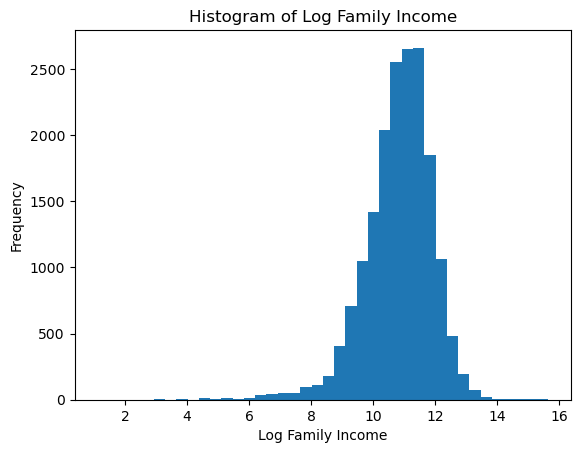

In [7]:
plt.hist(psid["log_income"], bins=40)
plt.xlabel("Log Family Income")
plt.ylabel("Frequency")
plt.title("Histogram of Log Family Income")
plt.show()

## Scatterplots of Income vs Key Predictors by Year

Plotting the scatterplots of log family income against non binary predictors

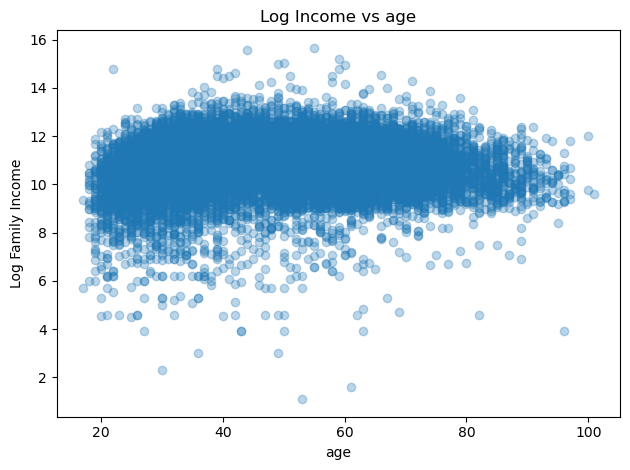

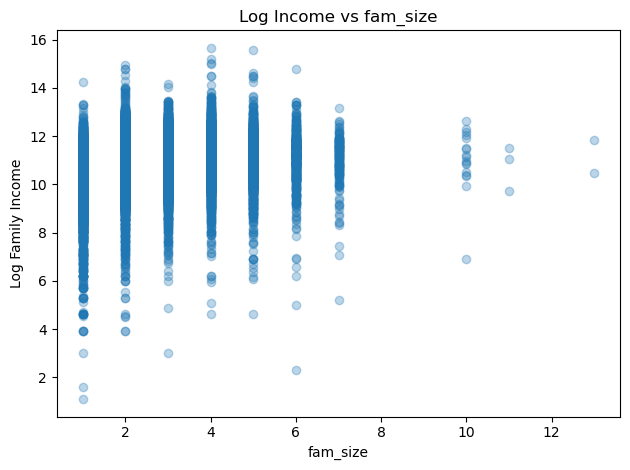

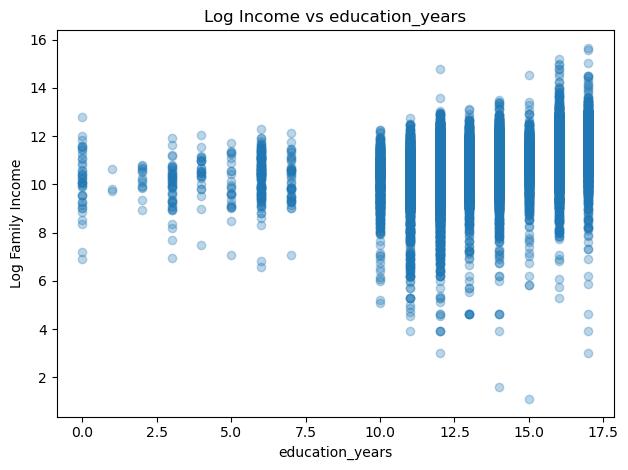

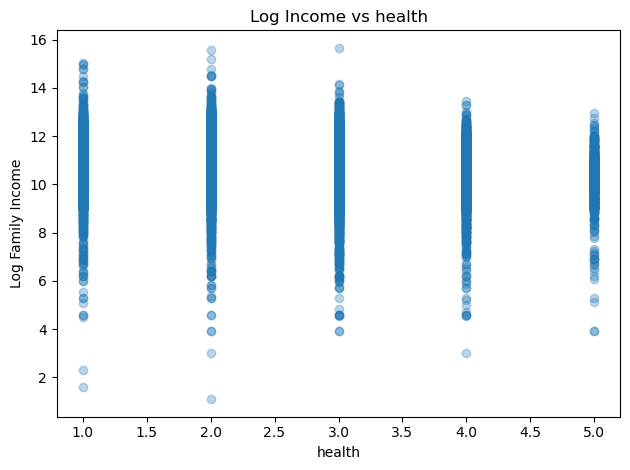

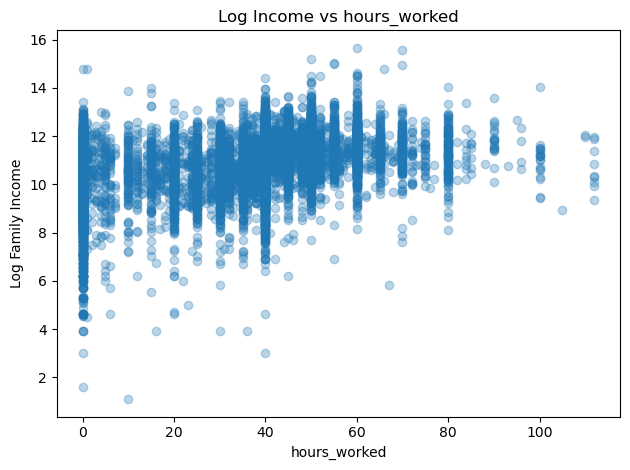

In [8]:
predictor_names = [
    "age", "fam_size", "education_years", "health",
    "hours_worked"
]

for var in predictor_names:
    plt.scatter(psid[var], psid["log_income"], alpha=0.3)
    plt.xlabel(var)
    plt.ylabel("Log Family Income")
    plt.title(f"Log Income vs {var}")
    plt.tight_layout()
    plt.show()


## Building the Modeling Dataset and Train–Test Split

#### I dropped the rows with any missing values

#### I used my predictors as X and log_income as y and used an 80/20 split

In [9]:
model_data = psid.dropna(subset=[
    "log_income", "age", "fam_size", "education_years",
    "sex_male", "health", "hours_worked",
    "own_own", "own_rent", "spouse_inc_yes"
]).copy()

X = model_data[[
    "age", "fam_size", "education_years",
    "sex_male", "health", "hours_worked",
    "own_own", "own_rent", "spouse_inc_yes"
]]
y = model_data["log_income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression

### I'm now fitting the model

### I then calculate RMSE and R^2

In [10]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lr = linreg.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R^2:", lr_r2)

Linear Regression RMSE: 0.6326892078882635
Linear Regression R^2: 0.34172351843780624


### I ran an OLS summary to check if our variables were significant.

#### It showed the sex of the head person had a high p-value and was not statistically significant in predicting household income

In [11]:
X_sm = sm.add_constant(X)

ols_full = sm.OLS(y, X_sm).fit()
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     586.0
Date:                Mon, 17 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:17:55   Log-Likelihood:                -8291.4
No. Observations:                8556   AIC:                         1.660e+04
Df Residuals:                    8546   BIC:                         1.667e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.2523      0.118     

### When using a KNN model you need to choose a value of k

#### I used the elbow method

### By looking at the graph, when k=30 that is when improvements in RMSE levels off

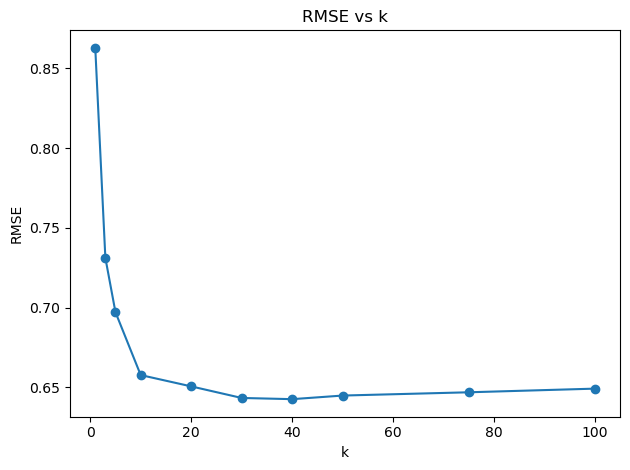

In [12]:
ks = [1,3,5,10,20,30,40,50,75,100]
rmses = []

for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmses.append(rmse)

plt.plot(ks, rmses, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs k")
plt.tight_layout()
plt.show()

### I fit the model and computed RMSE and R^2

In [13]:
knn_final = KNeighborsRegressor(n_neighbors=30)
knn_final.fit(X_train, y_train)

knn_pred = knn_final.predict(X_test)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

print("KNN RMSE:", knn_rmse)
print("KNN R^2:", knn_r2)

KNN RMSE: 0.6433995439456835
KNN R^2: 0.31924790962665306


#### When looking at the RMSE and R^2 of our Linear Regression and KNN models, we see that they are similar, but the linear regression model performs better. A lower RMSE and higher R^2 is better.

In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN"
    ],
    "RMSE": [
        lr_rmse,
        knn_rmse
    ],
    "R^2": [
        lr_r2,
        knn_r2
    ]
})

results.round(4)

,Model,RMSE,R^2
0,Linear Regression,0.6327,0.3417
1,KNN,0.6434,0.3192


#### Because our linear regression model performed better I decided to run the same model, but split it by year, to see possible changes in our model's coeficicents, seeing how the same variables may change in influence over time.

#### We also see that our 2013 model performed better

In [15]:
X_cols = ["age","fam_size","education_years","sex_male","health",
          "hours_worked","own_own","own_rent","spouse_inc_yes"]

data13 = model_data[model_data["survey_year"] == 2013].dropna(subset=X_cols)
data23 = model_data[model_data["survey_year"] == 2023].dropna(subset=X_cols)

X13 = data13[X_cols]
y13 = data13["log_income"]

X23 = data23[X_cols]
y23 = data23["log_income"]

model13 = LinearRegression().fit(X13, y13)
model23 = LinearRegression().fit(X23, y23)

r2_2013 = model13.score(X13, y13)
r2_2023 = model23.score(X23, y23)

print("R^2 2013:", r2_2013)
print("R^2 2023:", r2_2023)

R^2 2013: 0.4233723648130573
R^2 2023: 0.39197279524488216


#### We can now look at the coefficients and see how things have changed from 2013 to 2023 in relation to family income.

In [16]:
coef_df = pd.DataFrame({
    "coef_2013": model13.coef_,
    "coef_2023": model23.coef_
}, index=X_cols)

coef_df.round(3)

,coef_2013,coef_2023
age,0.012,0.009
fam_size,0.027,0.027
education_years,0.102,0.101
sex_male,0.000,0.186
health,-0.046,-0.080
hours_worked,0.014,0.012
own_own,0.659,0.464
own_rent,0.317,0.156
spouse_inc_yes,0.363,0.433


##### Age has had a slightly weaker effect over time
##### Family Size has had no change
##### Education has had basically no change
##### In 2013 sex made no difference, but in 2023 a man being the head person is associated with having a higher household income
##### Health had an even stronger negative association in 2023 compared to 2013
##### Hours worked was very similar
##### Both owning a home and renting both saw a steep fall
##### Having a spouse with income saw a significant rise from 2013 to 2023